# Bessel function of the first kind (J0)

**MLP**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn    # import Bessel function of the first kind

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
class MLP_2_2_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 2),   # input layer (2 variables -> 2 nodes)
            nn.ReLU(),
            nn.Linear(2, 2),   # hidden layer
            nn.ReLU(),
            nn.Linear(2, 1)    # output layer
        )

    def forward(self, x):
        return self.model(x)

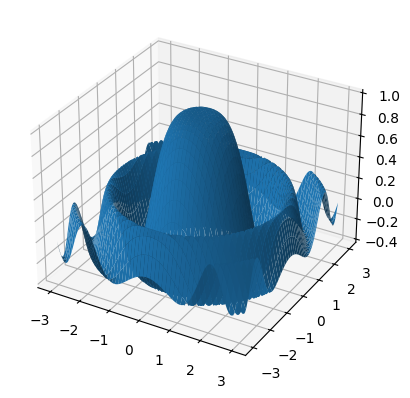

In [3]:
#x = np.linspace(0, 3, 100) 
#y = np.linspace(0, 3, 100)

# expanded the range to [-3,3] + more data points
x = np.linspace(-3, 3, 400) 
y = np.linspace(-3, 3, 400)
x, y = np.meshgrid(x, y)

f = lambda x,y: jn(0, x**2 + y**2)  # Bessel function of the first kind, order 0

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, f(x, y))

In [10]:
# Convert to PyTorch input format (N,2)
X = torch.tensor(
    np.stack([x.ravel(), y.ravel()], axis=1),
    dtype=torch.float32
)

bessel = torch.tensor(jn(0, X[:, 0].numpy()**2 + X[:, 1].numpy()**2), dtype=torch.float32).view(-1, 1)

# Initialize model
model = MLP_2_2_1()

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 2000

for epoch in range(epochs):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, bessel)

    # Backprop
    optimizer.zero_grad()   # claers old gradients from the previous iteration
    loss.backward()         # computes the gradient of the loss w.r.t. each parameter
    optimizer.step()        # updates the parameters based on the computed gradients

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.515429
Epoch 200, Loss: 0.121557
Epoch 400, Loss: 0.121421
Epoch 600, Loss: 0.117029
Epoch 800, Loss: 0.117020
Epoch 1000, Loss: 0.117020
Epoch 1200, Loss: 0.117020
Epoch 1400, Loss: 0.117020
Epoch 1600, Loss: 0.117020
Epoch 1800, Loss: 0.117020


In [11]:
#x_grid = np.linspace(0, 3, 101)
#y_grid = np.linspace(0, 3, 101)

# expanded the range to [-3,3] + more data points
x_grid = np.linspace(-3, 3, 401)
y_grid = np.linspace(-3, 3, 401)

X1_grid, X2_grid = np.meshgrid(x_grid, y_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32
)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z = model(grid_points).numpy()

# Reshape to grid
Z = Z.reshape(X1_grid.shape)

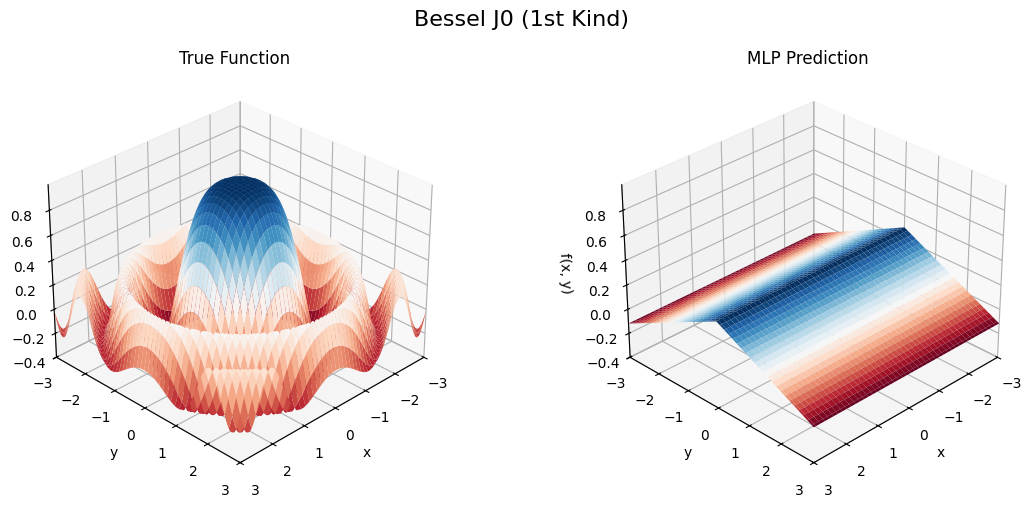

In [12]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(x, y, f(x, y), cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# --- MLP prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z, cmap='RdBu')

ax2.set_title("MLP Prediction")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x, y)")

# --- Make axes identical ---
zmin = min(f(x,y).min(), Z.min())
zmax = max(f(x,y).max(), Z.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Bessel J0 (1st Kind)", fontsize=16)
plt.tight_layout()
plt.show()

**KAN**

In [13]:
from kan import *
from kan.spline import *
import torch
import matplotlib.pyplot as plt
from scipy.special import jn    # import Bessel function of the first kind

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [14]:
f_KAN = lambda x: jn(0, x[:,[0]]**2 + x[:,[1]]**2)  # Bessel function of the first kind, order 0

bessel_KAN = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device) # a [2,2,1] tree

checkpoint directory created: ./model
saving model version 0.0


In [15]:
#dataset = create_dataset(f_KAN, n_var=2, ranges=[0, 3], train_num=100, device=device)
    # generate 2D train_input, 1D train_label (output), 2D test_input, 1D test_label (output)
    # 2D inputs are randomly generated within the specified range

    # didn't know this the first time when I tried, but create_dataset has a default test_num=1000

#dataset = create_dataset(f_KAN, n_var=2, ranges=[-3, 3], train_num=400, test_num=400, device=device)
    # expanded the range to [-3,3]; test+train with 400 data points each

dataset = create_dataset(f_KAN, n_var=2, ranges=[0, 3], train_num=100, test_num=100, device=device)
    # changed back to [0,3]

In [45]:
dataset

{'train_input': tensor([[1.4888, 1.5631],
         [2.3047, 2.4669],
         [0.2654, 0.3661],
         [0.3961, 0.4702],
         [0.9223, 0.6290],
         [1.9022, 2.5499],
         [1.4703, 0.9608],
         [2.6893, 2.7652],
         [1.3669, 2.0424],
         [1.8969, 1.6899],
         [1.0467, 1.4888],
         [1.2052, 1.2035],
         [0.0670, 1.6882],
         [0.5066, 1.1575],
         [0.8817, 1.4895],
         [1.5556, 1.6914],
         [2.0930, 0.3267],
         [2.4000, 0.7138],
         [0.4831, 2.7112],
         [0.8468, 0.2827],
         [2.0448, 1.3923],
         [2.7456, 2.9839],
         [1.1913, 2.0419],
         [2.6225, 1.5425],
         [1.2582, 0.2001],
         [1.6587, 2.2431],
         [2.8582, 0.4316],
         [0.1085, 1.0742],
         [0.5557, 0.9967],
         [1.1203, 1.2779],
         [0.9153, 1.5164],
         [2.7960, 2.7372],
         [0.5277, 1.6873],
         [0.8095, 2.8435],
         [0.4520, 2.4176],
         [0.0952, 0.5517],
         [0.6

**enforce symmetry**
- Created dataset in the first quadrant --> rotate it 4 times

In [16]:
# dataset: a dictionary with keys: 'train_input', 'train_label', 'test_input', 'test_label'
#   inputs: tensors of shape (N, 2) where N is the number of data points; each row is a 2D input (x1, x2)
#   labels: tensors of shape (N, 1) where N is the number of data points; each row is the corresponding output f(x1, x2)
dataset.keys()

dict_keys(['train_input', 'test_input', 'train_label', 'test_label'])

In [17]:
# rotation matrix
def rotate_90(data_pair):
    x, y = data_pair
    return torch.stack([-y, x])

In [18]:
# train
quad2_train = torch.zeros_like(dataset['train_input'])
quad3_train = torch.zeros_like(dataset['train_input'])
quad4_train = torch.zeros_like(dataset['train_input'])

for i in range(len(dataset['train_input'])):
    quad2_train[i] = rotate_90(dataset['train_input'][i])
    quad3_train[i] = rotate_90(quad2_train[i])
    quad4_train[i] = rotate_90(quad3_train[i])

# test
quad2_test = torch.zeros_like(dataset['test_input'])
quad3_test = torch.zeros_like(dataset['test_input'])
quad4_test = torch.zeros_like(dataset['test_input'])

for i in range(len(dataset['test_input'])):
    quad2_test[i] = rotate_90(dataset['test_input'][i])
    quad3_test[i] = rotate_90(quad2_test[i])
    quad4_test[i] = rotate_90(quad3_test[i])

In [19]:
# combine original + rotated data
whole_train_input = torch.vstack([dataset['train_input'], quad2_train, quad3_train, quad4_train])
whole_test_input = torch.vstack([dataset['test_input'], quad2_test, quad3_test, quad4_test])
whole_train_label = torch.vstack([dataset['train_label'], dataset['train_label'], dataset['train_label'], dataset['train_label']])
whole_test_label = torch.vstack([dataset['test_label'], dataset['test_label'], dataset['test_label'], dataset['test_label']])

whole_dataset = {
    'train_input': whole_train_input,
    'test_input': whole_test_input,
    'train_label': whole_train_label,
    'test_label': whole_test_label
}
# now 400 train + 400 test data points

In [20]:
bessel_KAN.fit(whole_dataset, opt='LBFGS', steps=2000)

| train_loss: 1.20e-01 | test_loss: 1.74e-01 | reg: 8.08e+00 | : 100%|█| 2000/2000 [00:40<00:00, 49.


saving model version 0.1


{'train_loss': [array(0.2403299, dtype=float32),
  array(0.21854502, dtype=float32),
  array(0.19853914, dtype=float32),
  array(0.1860085, dtype=float32),
  array(0.179541, dtype=float32),
  array(0.22272137, dtype=float32),
  array(0.21585287, dtype=float32),
  array(0.2043275, dtype=float32),
  array(0.19658156, dtype=float32),
  array(0.18835731, dtype=float32),
  array(0.18679032, dtype=float32),
  array(0.1851158, dtype=float32),
  array(0.1838179, dtype=float32),
  array(0.18295528, dtype=float32),
  array(0.18183036, dtype=float32),
  array(0.18093146, dtype=float32),
  array(0.17920087, dtype=float32),
  array(0.17740783, dtype=float32),
  array(0.17525636, dtype=float32),
  array(0.17368387, dtype=float32),
  array(0.17270061, dtype=float32),
  array(0.17103752, dtype=float32),
  array(0.17069381, dtype=float32),
  array(0.17043334, dtype=float32),
  array(0.17030813, dtype=float32),
  array(0.16957599, dtype=float32),
  array(0.169314, dtype=float32),
  array(0.16901155, dty

In [21]:
#x_grid = np.linspace(0, 3, 101)
#y_grid = np.linspace(0, 3, 101)

# expanded the range to [-3,3] + more data points
x_grid = np.linspace(-3, 3, 401)
y_grid = np.linspace(-3, 3, 401)

X1_grid, X2_grid = np.meshgrid(x_grid, y_grid)

Z_true = jn(0, X1_grid**2 + X2_grid**2)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)


# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = bessel_KAN(grid_points).numpy()
    # use the trained model to predict for the 401x401 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)


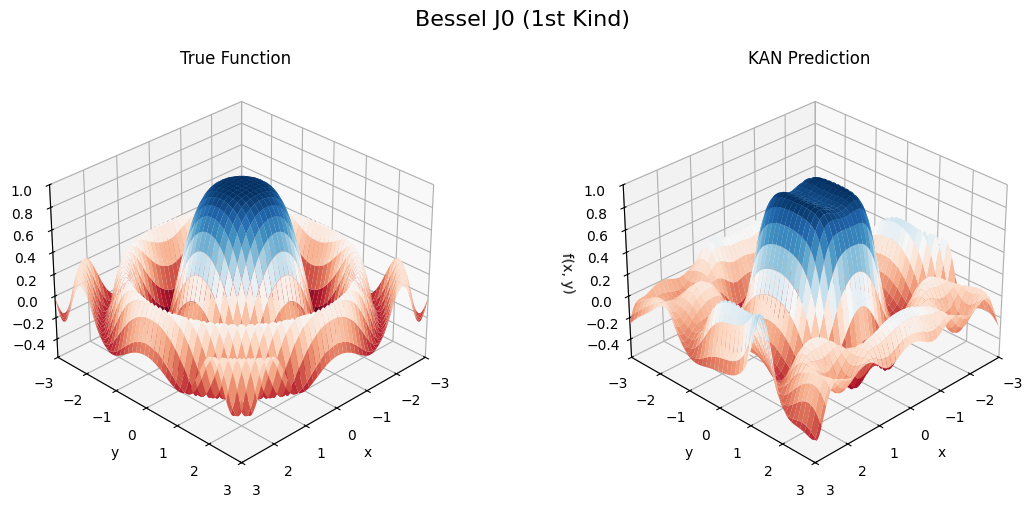

In [22]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x, y)")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Bessel J0 (1st Kind)", fontsize=16)
plt.tight_layout()
plt.show()

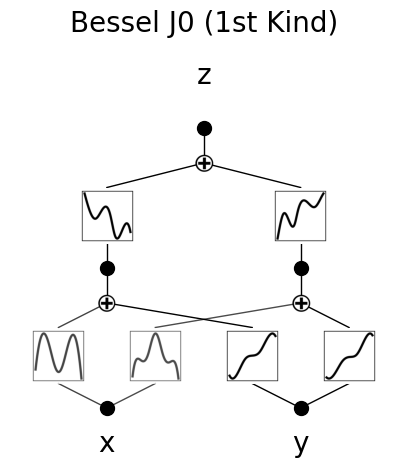

In [23]:
bessel_KAN.plot(in_vars=['x', 'y'], out_vars=['z'], title="Bessel J0 (1st Kind)")

**plot out input (x,y)**
* dataset created by calling the "create_dataset" function in utils.py in pykan

In [ ]:
# train_input: [x,y]        test_input: [x,y]
# train_label: [z]          test_label: [z]

# This approach flattens the array --> not desirable
'''
# train and test inputs are 2D tensors
train_x = dataset["train_input"][:, 0].detach().numpy()  # x-coordinates: tensor -> numpy array
train_y = dataset["train_input"][:, 1].detach().numpy()  # y-coordinates: tensor -> numpy array
train_x, train_y = np.meshgrid(train_x, train_y)

test_x = dataset["test_input"][:, 0].detach().numpy()  # x-coordinates: tensor -> numpy array
test_y = dataset["test_input"][:, 1].detach().numpy()  # y-coordinates: tensor -> numpy array
test_x, test_y = np.meshgrid(test_x, test_y) 
'''

In [24]:
train_data = dataset["train_input"].detach().numpy()

test_data = dataset["test_input"].detach().numpy()

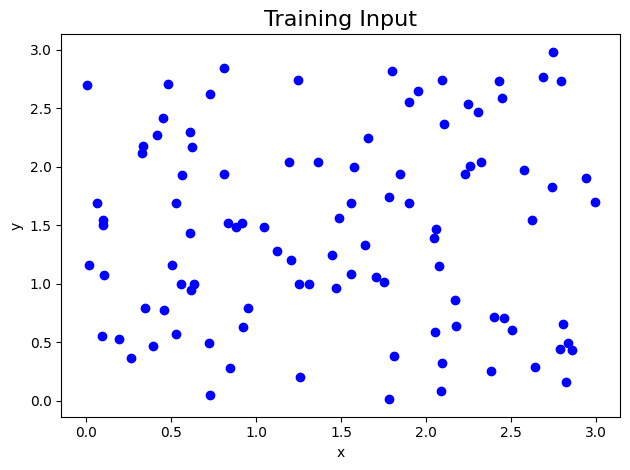

In [25]:
# to generate a scatter plot of the input coordinates
fig = plt.figure()
for i in range(len(train_data)):
    x = train_data[i][0]    # x-coordinates
    y = train_data[i][1]    # y-coordinates
    plt.scatter(x, y, color='blue')  # plot each point with a small size
#plt.scatter(train_data, s=0.1)
plt.title("Training Input", fontsize=16)
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

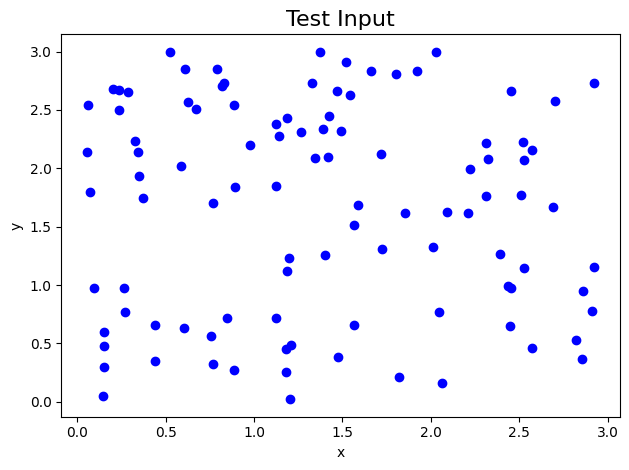

In [26]:
fig = plt.figure()
for i in range(len(test_data)):
    x = test_data[i][0]    # x-coordinates
    y = test_data[i][1]    # y-coordinates
    plt.scatter(x, y, color='blue')  # plot each point with a small size
#plt.scatter(test_x, test_y, s=0.1)
plt.title("Test Input", fontsize=16)
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**extract activation functions on edges**

In [ ]:
# model.get_fun(l,i,j)      gives a plot on the edge connecting neuron i in layer l to neuron j in layer l+1
#                           returns input and output coordiantes

# model.suggest_symbolic(l,i,j)     suggests a symbolic function for the function on the edge connecting neuron i in layer l to neuron j in layer l+1
# model.fix_symbolic(l,i,j, formula)   manually sets the symbolic formula for the edge connecting neuron i in layer l to neuron j in layer l+1; this will be used for auto_symbolic if the edge is not trained
# model.auto_symbolic()             automatically applies suggest_symbolic to all edges in the network and prints the results
# model.symbolic_formula()          prints the symbolic formula for the overall function represented by the network

# if x -> x1, x2, y -> y1,y2, then x1_post + y1_post -> n1, x2_post + y2_post -> n2, n1_post + n2_post -> z
#x1, x1_post= bessel_KAN.get_fun(0,0,0)  # edge connecting neuron 0 in layer 0 to neuron 0 in layer 1
#bessel_KAN.act_fun[0].coef

bessel_KAN.act_fun[0].coef.size()   #[2,2,6] (in_dim, out_dim, num_coef = grid + k)

torch.Size([2, 2, 6])

(array([-3., -3., -3., ...,  3.,  3.,  3.], dtype=float32), array([-0.20631713, -0.20631713, -0.20631713, ..., -0.38037586,
       -0.38037586, -0.38037586], dtype=float32))
----------------------------------------
x range: [-3.00 , 3.00 ]
y range: [-0.38 , 0.49 ]


(array(-3., dtype=float32),
 array(3., dtype=float32),
 array(-0.38037586, dtype=float32),
 array(0.49010956, dtype=float32))

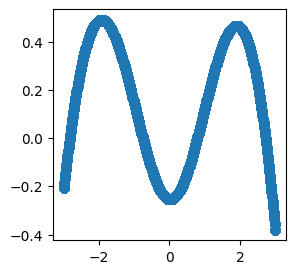

In [38]:
print(bessel_KAN.get_fun(0,0,0))
print('-'*40)
bessel_KAN.get_range(0,0,0)

[-3. -3. -3. -3. -3. -3. -3. -3. -3. -3.]


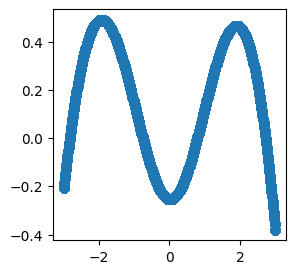

In [44]:
input=bessel_KAN.get_fun(0,0,0)[0]
print(input[0:10])